In [ ]:
## Cell 1-Load libraries and dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Load dataset as data framew
df = pd.read_csv("credit_default.csv")


# Shape of dataset
print("Shape:", df.shape)

# Show first 10 rows as a clean table
display(df.head())


# Quick summary of target
print(df["default"].value_counts(normalize=True))




Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2.0,2.0,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1.0,2.0,0.0,0.0,0.0,2.0,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
# Cell 2-Data Cleaning & Preparation


# Check missing values
total_missing = df.isnull().sum().sum()
print("Total missing values in the dataset:", total_missing)

# Unique values per column (to spot categorical vars)
print("\nUnique values per column:")
print(df.nunique())

# Convert categorical variables to category type for clarity
cat_vars = ["SEX", "EDUCATION", "MARRIAGE"]
df[cat_vars] = df[cat_vars].astype("category")

pay_vars = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Convert to integer type first and then to category type
df[pay_vars] = df[pay_vars].astype(int).astype("category")


# apply one hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)






Total missing values in the dataset: 0

Unique values per column:
LIMIT_BAL       81
SEX              2
EDUCATION        7
MARRIAGE         4
AGE             56
PAY_1           11
PAY_2           11
PAY_3           11
PAY_4           11
PAY_5           10
PAY_6           10
BILL_AMT1    22723
BILL_AMT2    22346
BILL_AMT3    22026
BILL_AMT4    21548
BILL_AMT5    21010
BILL_AMT6    20604
PAY_AMT1      7943
PAY_AMT2      7899
PAY_AMT3      7518
PAY_AMT4      6937
PAY_AMT5      6897
PAY_AMT6      6939
default          2
dtype: int64


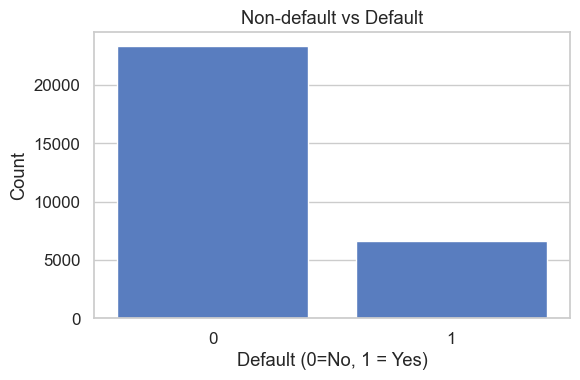

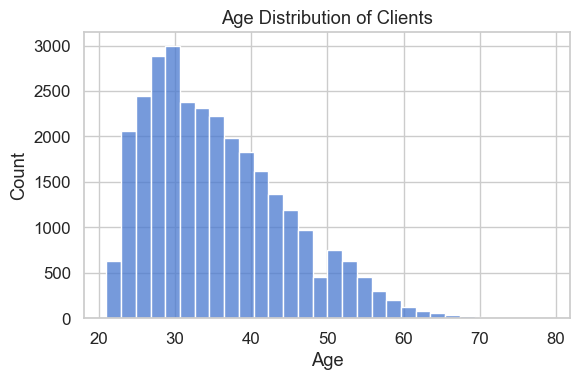

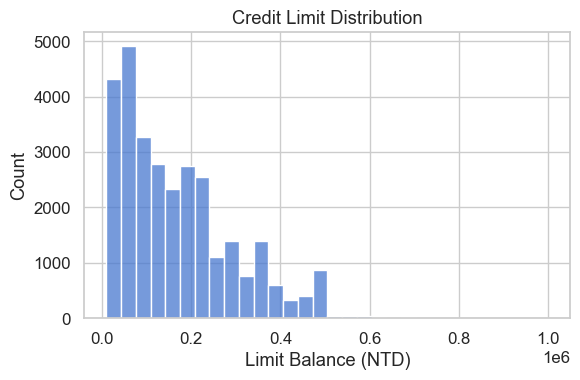

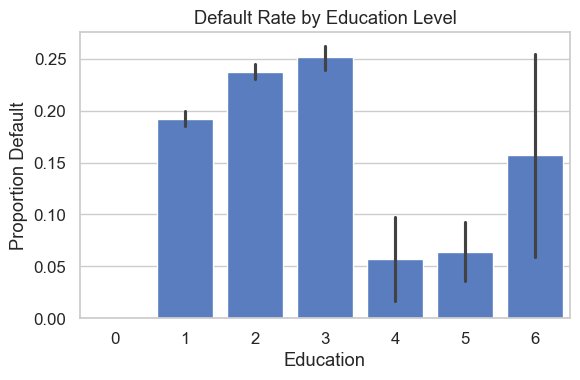

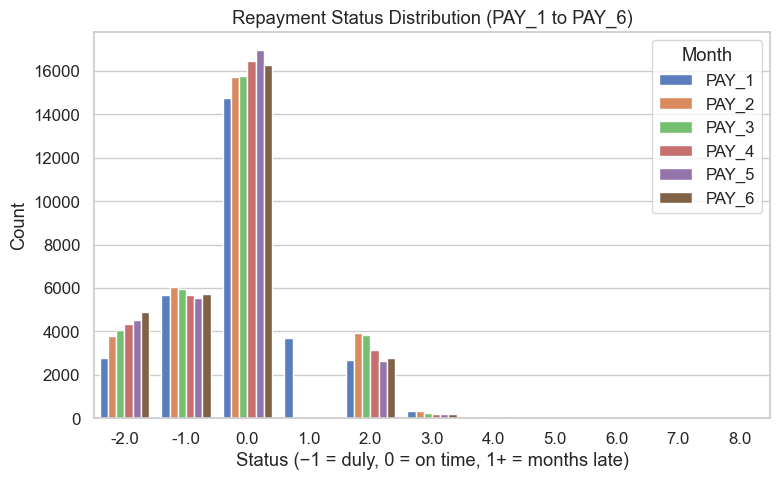

In [62]:
# Cell 3: Exploratory Data Analysis (EDA)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# 1. Default distribution
plt.figure(figsize=(6,4))
sns.countplot(x="default", data=df)
plt.title("Non-default vs Default")
plt.xlabel("Default (0=No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["AGE"], bins=30, kde=False)
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Credit limit distribution
plt.figure(figsize=(6,4))
sns.histplot(df["LIMIT_BAL"], bins=30, kde=False)
plt.title("Credit Limit Distribution")
plt.xlabel("Limit Balance (NTD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4. Default rate by education level
plt.figure(figsize=(6,4))
sns.barplot(x="EDUCATION", y="default", data=df, estimator=np.mean)
plt.title("Default Rate by Education Level")
plt.xlabel("Education")
plt.ylabel("Proportion Default")
plt.tight_layout()
plt.show()

# 5. Repayment status distribution (PAY_1 to PAY_6)
pay_cols = [f"PAY_{i}" for i in range(1,7)]
long_df = df[pay_cols].melt(var_name="Month", value_name="Status")

plt.figure(figsize=(8,5))
sns.countplot(data=long_df, x="Status", hue="Month")
plt.title("Repayment Status Distribution (PAY_1 to PAY_6)")
plt.xlabel("Status (−1 = duly, 0 = on time, 1+ = months late)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



In [64]:
#Cell 4-Train/test split + preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df_encoded.drop(columns=['default'])
y = df_encoded['default']

# Train/test split (70/30, stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Check dimensions and class proportions


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


print("Train class proportions:", y_train.value_counts(normalize=True).to_dict())
print("Test class proportions:", y_test.value_counts(normalize=True).to_dict())

# Standardize continuous variables
scaler = StandardScaler()

# Scale numeric predictors only, not categorical ones
numeric_vars = ['LIMIT_BAL', 'AGE','BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3','BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
X_train_scaled = X_train.copy()
X_train_scaled[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_vars] = scaler.transform(X_test[numeric_vars])


Train shape: (21000, 82)
Test shape: (9000, 82)
Train class proportions: {0: 0.7773333333333333, 1: 0.22266666666666668}
Test class proportions: {0: 0.7822222222222223, 1: 0.21777777777777776}


In [67]:
# Cell 5: Linear Discriminant Analysis (LDA)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve

# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Predictions
y_pred = lda.predict(X_test_scaled)
y_prob = lda.predict_proba(X_test_scaled)[:, 1]


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Sensitivity (Recall for the positive class)
sensitivity = recall_score(y_test, y_pred)

# Specificity (Recall for the negative class)
# Note: scikit-learn doesn't have a direct specificity function, but we can compute it as:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# AUC
auc = roc_auc_score(y_test, y_prob)

print("LDA Performance:")
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("AUC:", round(auc, 3))


LDA Performance:
Accuracy: 0.819
Sensitivity: 0.362
Specificity: 0.946
AUC: 0.761


In [68]:
# Cell 6: Quadratic Discriminant Analysis (QDA)

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Fit QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

# Predictions
y_pred = qda.predict(X_test_scaled)
y_prob = qda.predict_proba(X_test_scaled)[:, 1]


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Sensitivity (Recall for the positive class)
sensitivity = recall_score(y_test, y_pred)

# Specificity (Recall for the negative class)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# AUC
auc = roc_auc_score(y_test, y_prob)

print("QDA Performance:")
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("AUC:", round(auc, 3))




QDA Performance:
Accuracy: 0.393
Sensitivity: 0.898
Specificity: 0.253
AUC: 0.731


c:\Users\au506673\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\au506673\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [70]:
# Cell 7: K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Hyperparameter tuning for k (choose odd numbers to avoid ties)
k_values = range(1, 11, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="roc_auc")
    cv_scores.append(scores.mean())

# Pick best k
best_k = k_values[np.argmax(cv_scores)]
print("Best k based on CV AUC:", best_k)

# Fit best model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Sensitivity (Recall for the positive class)
sensitivity = recall_score(y_test, y_pred)

# Specificity (Recall for the negative class)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

#auc
auc = roc_auc_score(y_test, y_prob)

print("KNN Performance (k =", best_k, "):")
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("AUC:", round(auc, 3))



Best k based on CV AUC: 9
KNN Performance (k = 9 ):
Accuracy: 0.81
Sensitivity: 0.314
Specificity: 0.948
AUC: 0.712


Plain Logistic Regression Performance:
Accuracy: 0.82
Sensitivity: 0.34
Specificity: 0.953
AUC: 0.647
Zero coefficients: 4
Total coefficients: 82

Lasso Logistic Regression Performance:
Accuracy: 0.82
Sensitivity: 0.341
Specificity: 0.953
AUC: 0.762


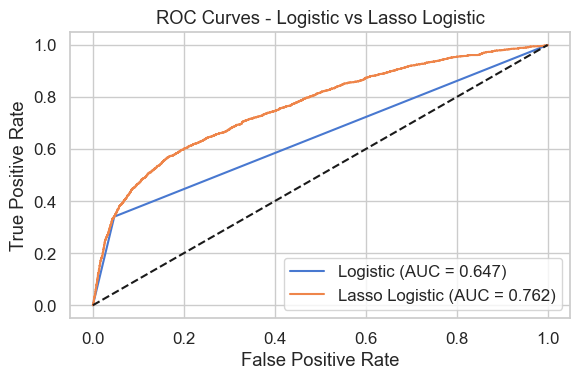

In [71]:
# Cell 8: Logistic Regression (Plain vs Lasso)

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# ----- Plain Logistic Regression -----
log_model = LogisticRegression(C=1e10, solver="liblinear").fit(X_train_scaled, y_train)
y_prob_log = log_model.predict(X_test_scaled)
y_pred_log = (y_prob_log >= 0.5)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_log)

# Sensitivity (Recall for the positive class)
sensitivity = recall_score(y_test, y_pred_log)

# Specificity (Recall for the negative class)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_log).ravel()
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_prob_log)

print("Plain Logistic Regression Performance:")
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("AUC:", round(auc, 3))



# ----- Lasso Logistic Regression -----
lasso_log = LogisticRegressionCV(cv=5, penalty="l1", solver="liblinear")
lasso_log.fit(X_train_scaled, y_train)

print("Zero coefficients:", np.sum(lasso_log.coef_[0] == 0))
print("Total coefficients:", len(lasso_log.coef_[0]))

y_pred_lasso = lasso_log.predict(X_test_scaled)
y_prob_lasso = lasso_log.predict_proba(X_test_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lasso)

# Sensitivity (Recall for the positive class)
sensitivity = recall_score(y_test, y_pred_lasso)

# Specificity (Recall for the negative class)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lasso).ravel()
specificity = tn / (tn + fp)

# AUC
auc = roc_auc_score(y_test, y_prob_lasso)


print("\nLasso Logistic Regression Performance:")
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("AUC:", round(auc, 3))


# ----- ROC curves comparison -----
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)

plt.figure(figsize=(6,4))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {roc_auc_score(y_test, y_prob_log):.3f})")
plt.plot(fpr_lasso, tpr_lasso, label=f"Lasso Logistic (AUC = {roc_auc_score(y_test, y_prob_lasso):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Logistic vs Lasso Logistic")
plt.legend()
plt.tight_layout()
plt.show()


